This code does the following:

* Use a configuration yaml file to plot the covariance matrix measurements.
* It will plot the measured lensing data vectors, and compare the diagnal terms of the JK covariance matrix with simulation variations.


In [16]:
## import libraries and modules
import numpy as np
import matplotlib.pyplot as plt
#import read_functions
from astropy.cosmology import FlatLambdaCDM
from astropy import units as u
from use_config import load_yaml_config
import os

## loading the yaml file that was used to generate measurements.
yaml_file = 'configs/t19lite.yml'
yaml_data = load_yaml_config(yaml_file)

## the simulation names and area of skies of the measurements
sim_names = yaml_data['inputfile']['filename_sets']
nskys = yaml_data['nsky']

Using config for:  Takahashi 2019
Info:  full-sky lensing maps and halos in lightcones
lightcones cover sky fraction of fsky=1/48, or 680 deg2,
480 realisations at z = 0.1, 0.3, 0.5, 0.7



Plot measurements

0 2
1 4
2 8
3 16


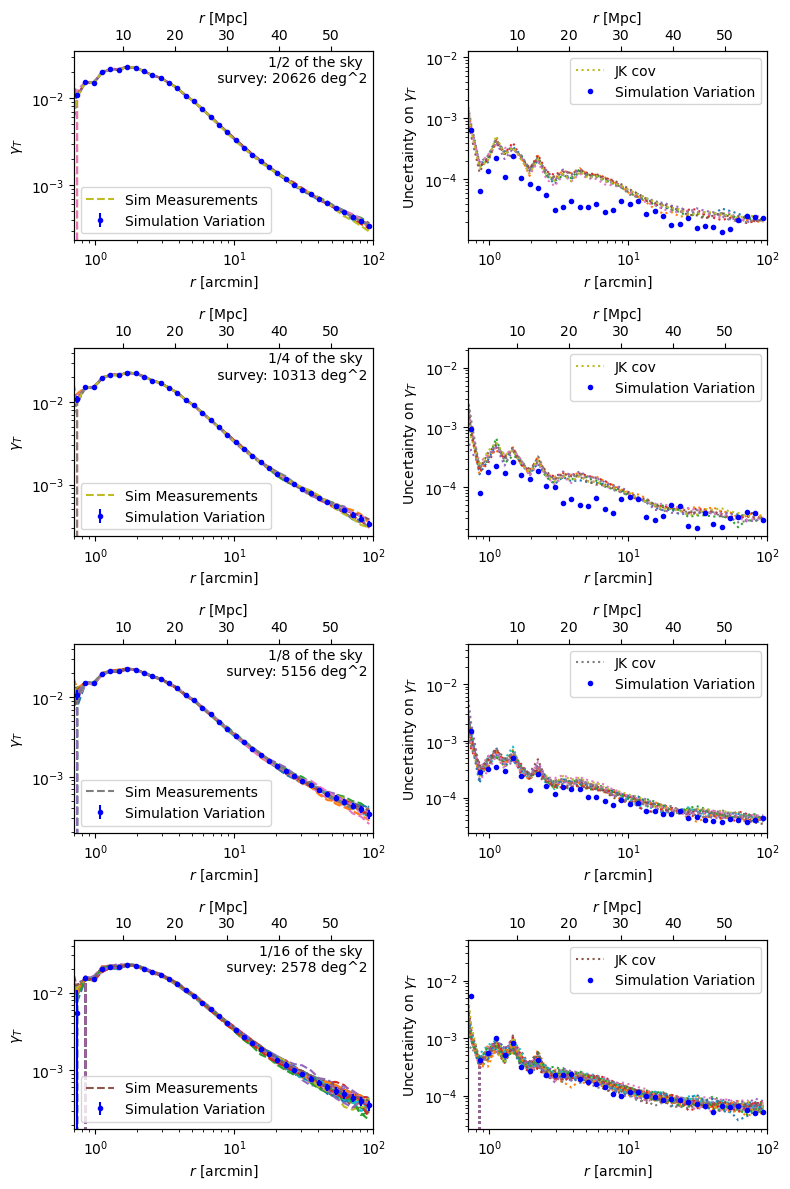

In [52]:
len_sim = len(sim_names)
len_skys=len(nskys)

fig, axs = plt.subplots(len_skys, 2, figsize=[8, 12])

for nn, nsky in enumerate(nskys):
    meas_rec=[]
    for ii in range(len_sim):
      #for jj in range(nsky):
      for jj in range(nsky):
          sim_name = sim_names[ii]
          file_name_ii_jj='measurements/datavector_'+sim_name+'_patchN%i_%i.txt'%(nsky, jj)
          if os.path.isfile(file_name_ii_jj):
              dat= np.genfromtxt(file_name_ii_jj)
              x_val = dat[:, 0]
              axs[nn, 0].plot(dat[:, 0], dat[:, 3], '--', label = 'Sim Measurements')

              if len(meas_rec) == 0:
                 meas_rec = dat[:, 3]
              else:
                 meas_rec = np.vstack((meas_rec, dat[:, 3]))       
          file_cov_ii_jj='measurements/cov_'+sim_name+'_patchN%i_%i.txt'%(nsky, jj)
          if os.path.isfile(file_cov_ii_jj):
              dat_cov= np.genfromtxt(file_cov_ii_jj)
              y_jk_err=np.sqrt(np.diag(dat_cov))
              axs[nn, 1].plot(x_val, y_jk_err, ':', label='JK cov ')
    
    if len(meas_rec) > 0:
        y_val=np.mean(meas_rec, axis=0)
        y_sim_err=np.std(meas_rec, axis=0)
        axs[nn, 0].errorbar(x_val, y_val, yerr=y_sim_err, fmt='b.', label='Simulation Variation')
        axs[nn, 1].errorbar(x_val, y_sim_err, fmt='b.', label='Simulation Variation')


        
    
    handles, labels = axs[nn, 0].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    print(nn, nsky)
    axs[nn, 0].text(0.98, 0.98, '1/%i of the sky \n survey: %i deg^2'%(nsky, 41252.96125/nsky), \
         transform=axs[nn, 0].transAxes, verticalalignment='top', horizontalalignment='right')
    axs[nn, 0].legend(by_label.values(), by_label.keys())
    axs[nn, 0].set_xscale('log')
    axs[nn, 0].set_yscale('log')
    axs[nn, 0].set_xlim(0.7, 100)
    axs[nn, 0].set_xlabel(r'$r$ [arcmin]')
    axs[nn, 0].set_ylabel(r'$\gamma_T$')

    handles, labels = axs[nn, 1].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    axs[nn, 1].legend(by_label.values(), by_label.keys())
    axs[nn, 1].set_xscale('log')
    axs[nn, 1].set_yscale('log')
    axs[nn, 1].set_xlim(0.7, 100)
    axs[nn, 1].set_xlabel(r'$r$ [arcmin]')
    axs[nn, 1].set_ylabel(r'Uncertainty on $\gamma_T$')


    
    ## convert angular scale to physical scale
    # Define the cosmology
    cosmo = FlatLambdaCDM(H0=70.0, Om0=0.279) # Example values
    # Define the redshift and angle
    z_cl=0.53 ## need to change depending on the cluster sample
    d_A = cosmo.comoving_distance(z_cl)
    
    ax2 = axs[nn, 0].twiny()
    mn, mx = axs[nn, 0].get_xlim()
    ax2.set_xlim( (mn* u.arcmin).to(u.radian).value*d_A.value, (mx* u.arcmin).to(u.radian).value*d_A.value)
    ax2.set_xlabel(r'$r$ [Mpc]')

    ax3 = axs[nn, 1].twiny()
    mn, mx = axs[nn, 1].get_xlim()
    ax3.set_xlim( (mn* u.arcmin).to(u.radian).value*d_A.value, (mx* u.arcmin).to(u.radian).value*d_A.value)
    ax3.set_xlabel(r'$r$ [Mpc]')
    
    
plt.tight_layout()

Plotting the errorbar from covariance and simulation variation